In [16]:
from pathlib import Path
import h5py

import os
from pathlib import Path

import astropy.constants as c
import astropy.units as u
import gofish as gf
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from disksimtool.model_utils import get_profile_from_fits

In [17]:
ROOT_DIR = Path(os.path.abspath('.'))
OBS_DIR = ROOT_DIR / 'observations'

distance = 56 * u.pc
incl = 7
PA = 0

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.


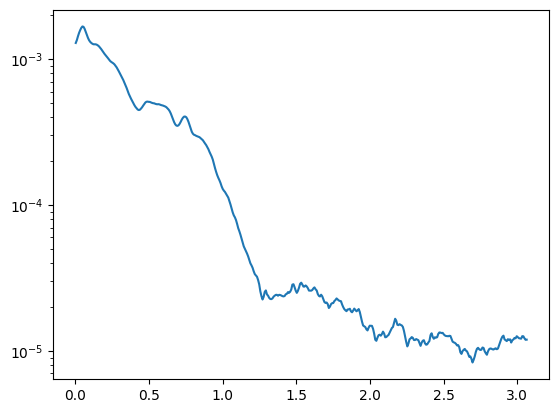

In [18]:
fits_ALMA_path = OBS_DIR / 'TWHya.ALMA_band7.30mas.fits'
icube_ALMA = gf.imagecube(fits_ALMA_path)
icube_ALMA.data[np.nonzero(icube_ALMA.data <= 0)] = 1e-30
icube_ALMA.data[np.nonzero(np.isnan(icube_ALMA.data))] = 1e-30
x_ALMA, y_ALMA, dy_ALMA, norm = get_profile_from_fits(icube_ALMA,
                                                   clip=6,
                                                   inc=incl,
                                                   PA=PA,
                                                   beam=icube_ALMA.beam,
                                                   dist=distance.value,
                                                  )
plt.semilogy(x_ALMA, y_ALMA)

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.


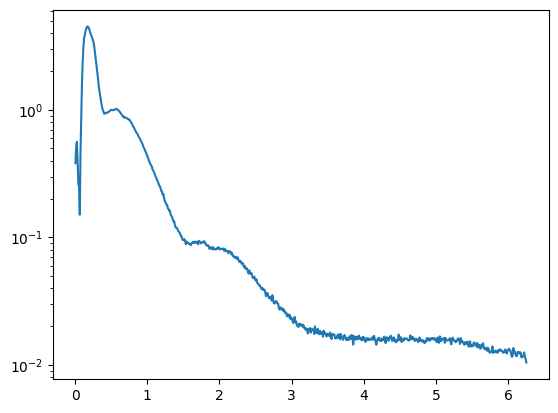

In [19]:
fits_SPHERE_path = OBS_DIR / 'SPHERE' / 'TWHya_dpimed_dbratio_Pper.fits'
icube_SPHERE = gf.imagecube(fits_SPHERE_path)
icube_SPHERE.data[np.nonzero(icube_SPHERE.data <= 0)] = 1e-30
icube_SPHERE.data[np.nonzero(np.isnan(icube_SPHERE.data))] = 1e-30
x_SPHERE, y_SPHERE, dy_SPHERE, _ = get_profile_from_fits(icube_SPHERE,
                                                      clip=6,
                                                      r_norm=0.5,
                                                      inc=incl,
                                                      PA=PA,
                                                      beam=icube_SPHERE.beam,
                                                      dist=distance.value,
                                                      )
plt.semilogy(x_SPHERE, y_SPHERE)

In [20]:
profiles_path = ROOT_DIR / 'profiles'

with h5py.File(profiles_path / 'observed_profiles.h5', 'w') as f:
    grp_1_65 = f.create_group('1.6_mu')
    x_1_65_data = grp_1_65.create_dataset('x', data=x_SPHERE)
    x_1_65_data.attrs['units'] = 'au'
    y_1_65_data = grp_1_65.create_dataset('y', data=y_SPHERE)
    y_1_65_data.attrs['units'] = 'arbitrary units'
    dy_1_65_data = grp_1_65.create_dataset('dy', data=dy_SPHERE)
    dy_1_65_data.attrs['units'] = 'arbitrary units'
    beam_1_65_data = grp_1_65.create_dataset('beam', data=icube_SPHERE.beam)

    grp_870_0 = f.create_group('870.0_mu')
    x_870_0_data = grp_870_0.create_dataset('x', data=x_ALMA)
    x_870_0_data.attrs['units'] = 'au'
    y_870_0_data = grp_870_0.create_dataset('y', data=y_ALMA)
    y_870_0_data.attrs['units'] = 'Jy / arcsec**2'
    dy_870_0_data = grp_870_0.create_dataset('dy', data=dy_ALMA)
    dy_870_0_data.attrs['units'] = 'Jy / arcsec**2'
    beam_870_0_data = grp_870_0.create_dataset('beam', data=icube_ALMA.beam)

### Check saved file

In [21]:
profiles_path = Path('/Users/rfranceschi/mysims/LESIA/profiles')
profiles_dict = {}
fpath = profiles_path / 'observed_profiles.h5'
with h5py.File(fpath, 'r') as f:
    for _key in f.keys():
        profiles_dict[_key] = {}
        for _profile_key in f[_key].keys():
            profiles_dict[_key][_profile_key] = f[_key][_profile_key][:]